# A09 - Interpretabilidade e Visualizacao

Este notebook reutiliza o modelo treinado no **A08 - Transfer Learning** para
analisar o desempenho no conjunto de teste sem realizar novo treinamento.

**Escopo desta entrega:**
- gerar e organizar predicoes para analise;
- construir visualizacoes quantitativas do modelo;
- interpretar os padroes observados nas figuras;
- deixar secoes-template para os itens 3, 4 e 5 do artefato.

## Roteiro do notebook

1. Carregar os artefatos do A08 (`history.csv` e `best_model.keras`).
2. Reconstruir o mesmo split treino/validacao/teste do A08.
3. Gerar predicoes em validacao e teste.
4. Comparar dois thresholds: `0.5` e `threshold_f1` ajustado na validacao.
5. Produzir curvas de treino, matrizes de confusao e distribuicoes de probabilidade.
6. Registrar interpretacao textual obrigatoria apos cada bloco principal.

In [ ]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import importlib.util
import sys

PYTHON_VERSION = sys.version_info[:3]
REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
    'tensorflow': 'tensorflow',
    'openpyxl': 'openpyxl',
}

if PYTHON_VERSION < (3, 10) or PYTHON_VERSION >= (3, 13):
    raise RuntimeError(
        'Este notebook foi preparado para rodar com TensorFlow em Python 3.10, 3.11 ou 3.12. '
        f'Ambiente atual: {sys.version.split()[0]}. '
        'Use Google Colab ou um ambiente local compativel.'
    )

missing = [
    pkg_name
    for module_name, pkg_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing:
    raise RuntimeError(
        'Pacotes ausentes para executar o notebook: ' + ', '.join(missing) + '. '
        'Instale as dependencias do projeto antes de prosseguir.'
    )

In [4]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from tensorflow import keras


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'src').exists():
        return cwd
    for parent in [cwd, *cwd.parents]:
        if (parent / 'src').exists():
            return parent
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')


PROJECT_ROOT = resolve_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from analise_visual.framework_visualizacao import (
    plot_confusion_matrix,
    plot_probability_distributions,
)
from inference import collect_binary_predictions
from models.cnn_data_prep import prepare_grouped_cnn_splits
from models.cnn_tf_data_pipeline import build_train_val_test_tf_data
from utils.metrics import select_threshold_by_f1

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_CSV = PROJECT_ROOT / 'data' / 'pixels_dataset.csv'
EXTRACTED_CODES_JSON = PROJECT_ROOT / 'data' / 'extracted_codes.json'
A08_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'a08_transfer_learning'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'a09_interpretabilidade_visualizacao'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HISTORY_PATH = A08_OUTPUT_DIR / 'history.csv'
MODEL_PATH = A08_OUTPUT_DIR / 'best_model.keras'

TEST_SIZE = 0.20
VAL_SIZE = 0.20
BATCH_SIZE = 8
TARGET_SIZE = (160, 160)
NORMALIZATION = 'zscore'
CLASS_NAMES = ('Negativo', 'Positivo')


def build_unique_sample_ids(image_ids):
    return [f'{str(image_id)}__tile_{idx:04d}' for idx, image_id in enumerate(image_ids)]


def compute_binary_metrics(y_true, y_prob, threshold, threshold_name):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'threshold_name': threshold_name,
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
    }

In [5]:
assert DATASET_CSV.exists(), f'Arquivo nao encontrado: {DATASET_CSV}'
assert EXTRACTED_CODES_JSON.exists(), f'Arquivo nao encontrado: {EXTRACTED_CODES_JSON}'
assert HISTORY_PATH.exists(), f'Arquivo nao encontrado: {HISTORY_PATH}'
assert MODEL_PATH.exists(), f'Arquivo nao encontrado: {MODEL_PATH}'

history_df = pd.read_csv(HISTORY_PATH)
phase1_epochs = int((history_df['phase'] == 'head_training').sum())
best_epoch_idx = int(history_df['val_loss'].idxmin())
best_epoch_num = best_epoch_idx + 1
best_epoch_row = history_df.iloc[best_epoch_idx]

artifact_overview = pd.DataFrame(
    [
        {'artefato': 'Historico consolidado do treino', 'caminho': str(HISTORY_PATH)},
        {'artefato': 'Melhor modelo salvo no A08', 'caminho': str(MODEL_PATH)},
        {'artefato': 'Saida do A09', 'caminho': str(OUTPUT_DIR)},
    ]
)

display(artifact_overview)
display(history_df.head())
print(f'Melhor epoca por val_loss: {best_epoch_num}')
print(f'Fase 1 (head training): {phase1_epochs} epocas')
print(f'Fase 2 (fine-tuning): {len(history_df) - phase1_epochs} epocas')

,artefato,caminho
0,Historico consolidado do treino,/Users/giovanna-britto/Documents/INTELI/PROJET...
1,Melhor modelo salvo no A08,/Users/giovanna-britto/Documents/INTELI/PROJET...
2,Saida do A09,/Users/giovanna-britto/Documents/INTELI/PROJET...


,epoch,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate,phase
0,0,0.598870,0.732662,0.456523,0.494253,0.614286,0.615955,0.610169,0.713569,0.496394,0.0,0.0,0.600242,0.000010,head_training
1,1,0.711864,0.550006,0.698932,0.679245,0.514286,0.798131,0.610169,0.728175,0.495006,0.0,0.0,0.626208,0.000010,head_training
2,2,0.790960,0.488813,0.714653,0.726027,0.757143,0.842190,0.610169,0.799544,0.483054,0.0,0.0,0.553744,0.000010,head_training
3,3,0.796610,0.471032,0.749219,0.757576,0.714286,0.856609,0.610169,0.897848,0.444017,0.0,0.0,0.520531,0.000005,head_training
4,4,0.768362,0.547637,0.704856,0.716418,0.685714,0.789920,0.610169,0.808060,0.461170,0.0,0.0,0.573068,0.000010,fine_tuning


Melhor epoca por val_loss: 1
Fase 1 (head training): 4 epocas
Fase 2 (fine-tuning): 6 epocas


In [6]:
df = pd.read_csv(DATASET_CSV)

split_data = prepare_grouped_cnn_splits(
    df,
    extracted_codes_path=EXTRACTED_CODES_JSON,
    data_format='channels_last',
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
)

tf_data = build_train_val_test_tf_data(
    split_data['X_train'],
    split_data['y_train'],
    split_data['X_val'],
    split_data['y_val'],
    split_data['X_test'],
    split_data['y_test'],
    batch_size=BATCH_SIZE,
    normalization=NORMALIZATION,
    resize_to=TARGET_SIZE,
    data_format='channels_last',
    target_channels=split_data['shape_info']['n_channels'],
    augment_train=True,
    seed=SEED,
)

model = keras.models.load_model(MODEL_PATH)

split_overview = pd.DataFrame(
    [
        {'split': 'train', 'samples': len(split_data['y_train']), 'classes': dict(zip(*np.unique(split_data['y_train'], return_counts=True)))},
        {'split': 'val', 'samples': len(split_data['y_val']), 'classes': dict(zip(*np.unique(split_data['y_val'], return_counts=True)))},
        {'split': 'test', 'samples': len(split_data['y_test']), 'classes': dict(zip(*np.unique(split_data['y_test'], return_counts=True)))},
    ]
)

display(split_overview)
print(f"Shape de entrada do modelo: {tf_data['train_meta']['input_shape']}")
print(f'Modelo carregado de: {MODEL_PATH}')

,split,samples,classes
0,train,177,"{0: 107, 1: 70}"
1,val,59,"{0: 36, 1: 23}"
2,test,59,"{0: 36, 1: 23}"


Shape de entrada do modelo: (160, 160, 9)
Modelo carregado de: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01/outputs/a08_transfer_learning/best_model.keras


## Item 1 - Geracao de predicoes e outputs do modelo

Embora o foco principal deste notebook seja o **item 2**, esta secao gera as
predicoes que servem de base para as visualizacoes quantitativas e para as
etapas seguintes de interpretabilidade.

In [7]:
val_sample_ids = build_unique_sample_ids(split_data['image_ids_val'])
test_sample_ids = build_unique_sample_ids(split_data['image_ids_test'])

val_predictions = collect_binary_predictions(
    model,
    tf_data['val_ds'],
    sample_ids=val_sample_ids,
)
val_predictions['image_id'] = split_data['image_ids_val']

threshold_f1 = select_threshold_by_f1(
    val_predictions['y_true'].to_numpy(),
    val_predictions['prob_pos'].to_numpy(),
    default_threshold=0.5,
)

test_predictions = collect_binary_predictions(
    model,
    tf_data['test_ds'],
    sample_ids=test_sample_ids,
)
test_predictions['image_id'] = split_data['image_ids_test']
test_predictions['pred_05'] = (test_predictions['prob_pos'] >= 0.5).astype(int)
test_predictions['pred_f1'] = (test_predictions['prob_pos'] >= threshold_f1).astype(int)
test_predictions['erro_05'] = (test_predictions['pred_05'] != test_predictions['y_true']).astype(int)
test_predictions['erro_f1'] = (test_predictions['pred_f1'] != test_predictions['y_true']).astype(int)

test_predictions = test_predictions[
    ['sample_id', 'image_id', 'y_true', 'prob_neg', 'prob_pos', 'pred_05', 'pred_f1', 'erro_05', 'erro_f1']
].copy()

test_predictions_path = OUTPUT_DIR / 'test_predictions.csv'
test_predictions.to_csv(test_predictions_path, index=False)

display(test_predictions.head(10))
print(f'threshold_f1 ajustado na validacao: {threshold_f1:.4f}')
print(f'Predicoes salvas em: {test_predictions_path}')
print(f'Numero de amostras no teste: {len(test_predictions)}')

,sample_id,image_id,y_true,prob_neg,prob_pos,pred_05,pred_f1,erro_05,erro_f1
0,23273__tile_0000,23273,0,0.802492,0.197508,0,1,0,1
1,23350__tile_0001,23350,0,0.881127,0.118873,0,0,0,0
2,23576B__tile_0002,23576B,0,0.893985,0.106015,0,0,0,0
3,23577__tile_0003,23577,0,0.641992,0.358008,0,1,0,1
4,25636__tile_0004,25636,1,0.700603,0.299397,0,1,1,0
5,31712__tile_0005,31712,1,0.628822,0.371178,0,1,1,0
6,31771__tile_0006,31771,1,0.708599,0.291401,0,1,1,0
7,31932__tile_0007,31932,1,0.678793,0.321207,0,1,1,0
8,31945__tile_0008,31945,1,0.725532,0.274468,0,1,1,0
9,31951__tile_0009,31951,1,0.818620,0.181380,0,1,1,0


threshold_f1 ajustado na validacao: 0.1345
Predicoes salvas em: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01/outputs/a09_interpretabilidade_visualizacao/test_predictions.csv
Numero de amostras no teste: 59


## Item 2.1 - Curvas de treino (loss e accuracy)

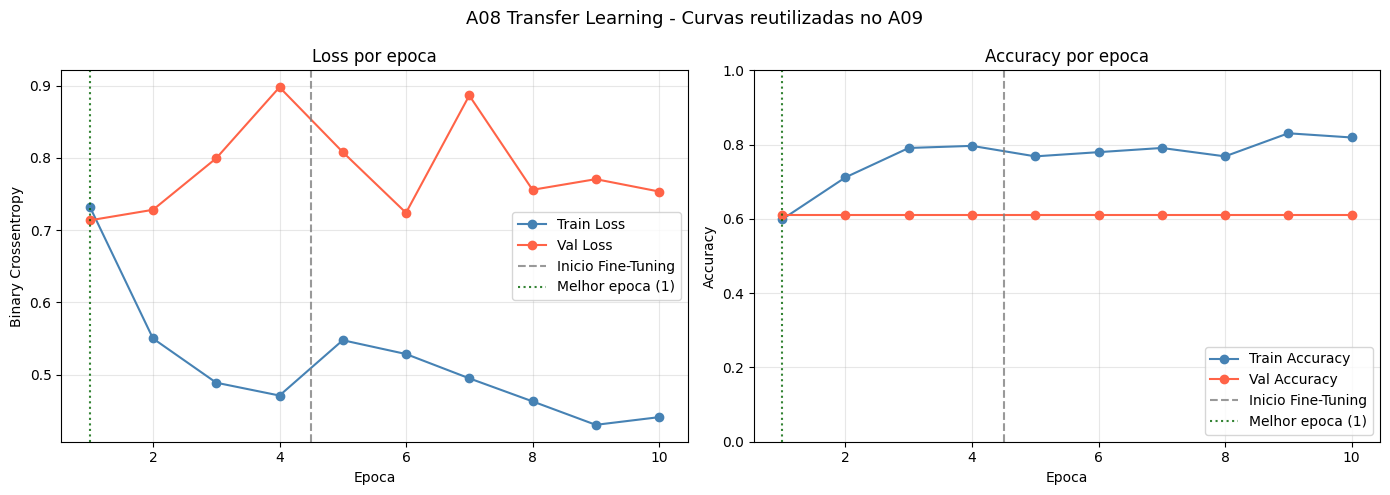

,melhor_epoca,melhor_fase,val_loss_min,val_accuracy_na_melhor_epoca,gap_accuracy_final
0,1,head_training,0.7136,0.6102,0.209


Grafico salvo em: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01/outputs/a09_interpretabilidade_visualizacao/training_curves_from_history.png


In [8]:
epochs = np.arange(1, len(history_df) + 1)
curves_path = OUTPUT_DIR / 'training_curves_from_history.png'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history_df['loss'], label='Train Loss', marker='o', color='steelblue')
axes[0].plot(epochs, history_df['val_loss'], label='Val Loss', marker='o', color='tomato')
axes[0].axvline(phase1_epochs + 0.5, color='gray', linestyle='--', alpha=0.8, label='Inicio Fine-Tuning')
axes[0].axvline(best_epoch_num, color='darkgreen', linestyle=':', alpha=0.8, label=f'Melhor epoca ({best_epoch_num})')
axes[0].set_title('Loss por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history_df['accuracy'], label='Train Accuracy', marker='o', color='steelblue')
axes[1].plot(epochs, history_df['val_accuracy'], label='Val Accuracy', marker='o', color='tomato')
axes[1].axvline(phase1_epochs + 0.5, color='gray', linestyle='--', alpha=0.8, label='Inicio Fine-Tuning')
axes[1].axvline(best_epoch_num, color='darkgreen', linestyle=':', alpha=0.8, label=f'Melhor epoca ({best_epoch_num})')
axes[1].set_title('Accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle('A08 Transfer Learning - Curvas reutilizadas no A09', fontsize=13)
fig.tight_layout()
fig.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()

curve_summary = pd.DataFrame(
    [
        {
            'melhor_epoca': best_epoch_num,
            'melhor_fase': best_epoch_row['phase'],
            'val_loss_min': round(float(best_epoch_row['val_loss']), 4),
            'val_accuracy_na_melhor_epoca': round(float(best_epoch_row['val_accuracy']), 4),
            'gap_accuracy_final': round(float(history_df.iloc[-1]['accuracy'] - history_df.iloc[-1]['val_accuracy']), 4),
        }
    ]
)

display(curve_summary)
print(f'Grafico salvo em: {curves_path}')

In [9]:
final_acc_gap = float(history_df.iloc[-1]['accuracy'] - history_df.iloc[-1]['val_accuracy'])
curve_reading = 'indica overfitting moderado ao final do treino' if final_acc_gap > 0.08 else 'permanece controlado ao final do treino'

curve_text = f'''    ### Interpretacao das curvas

As curvas mostram a transicao entre **head training** e **fine-tuning** sem necessidade de retreinar o modelo no A09.
A melhor epoca segundo `val_loss` ocorreu na **epoca {best_epoch_num}**, ja durante a fase **{best_epoch_row["phase"]}**, com `val_loss={best_epoch_row["val_loss"]:.4f}` e `val_accuracy={best_epoch_row["val_accuracy"]:.4f}`.

O gap final entre treino e validacao em acuracia foi de **{final_acc_gap:.4f}**, o que {curve_reading}. Em termos praticos, isso sugere que o modelo aprendeu um padrao util, mas que a generalizacao precisa ser lida em conjunto com as predicoes de validacao e teste, e nao apenas pelas metricas de treino.
'''

display(Markdown(curve_text))

    ### Interpretacao das curvas

As curvas mostram a transicao entre **head training** e **fine-tuning** sem necessidade de retreinar o modelo no A09.
A melhor epoca segundo `val_loss` ocorreu na **epoca 1**, ja durante a fase **head_training**, com `val_loss=0.7136` e `val_accuracy=0.6102`.

O gap final entre treino e validacao em acuracia foi de **0.2090**, o que indica overfitting moderado ao final do treino. Em termos praticos, isso sugere que o modelo aprendeu um padrao util, mas que a generalizacao precisa ser lida em conjunto com as predicoes de validacao e teste, e nao apenas pelas metricas de treino.


## Item 2.2 a 2.4 - Thresholds, matrizes de confusao e metricas por threshold

A partir das probabilidades do conjunto de teste, comparamos:
- `threshold=0.5` como referencia padrao;
- `threshold_f1` ajustado no conjunto de validacao para maximizar F1.

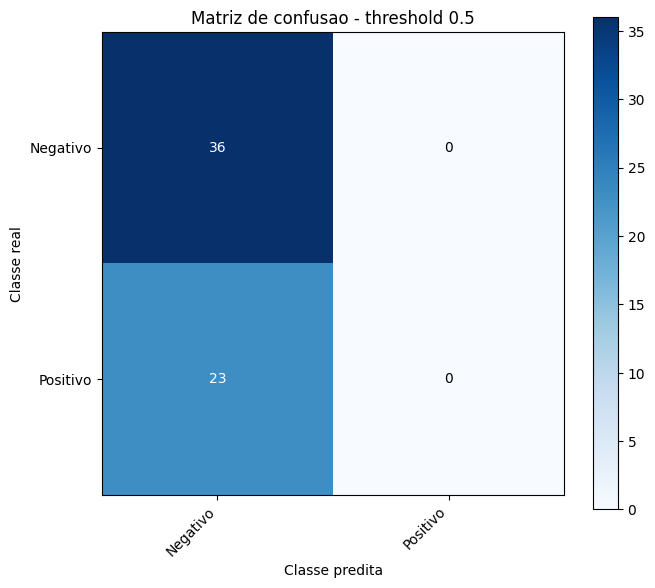

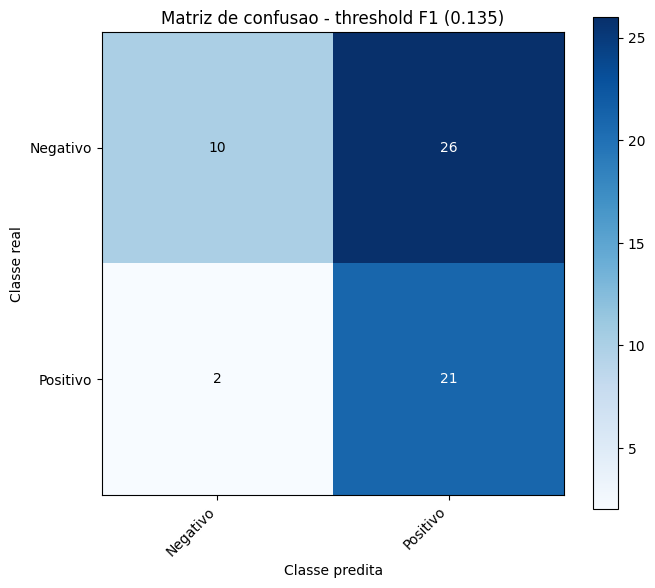

/Users/giovanna-britto/Documents/INTELI/PROJETO/g01/src/analise_visual/framework_visualizacao.py:121: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  matrix = np.divide(matrix, row_sums, where=row_sums != 0)


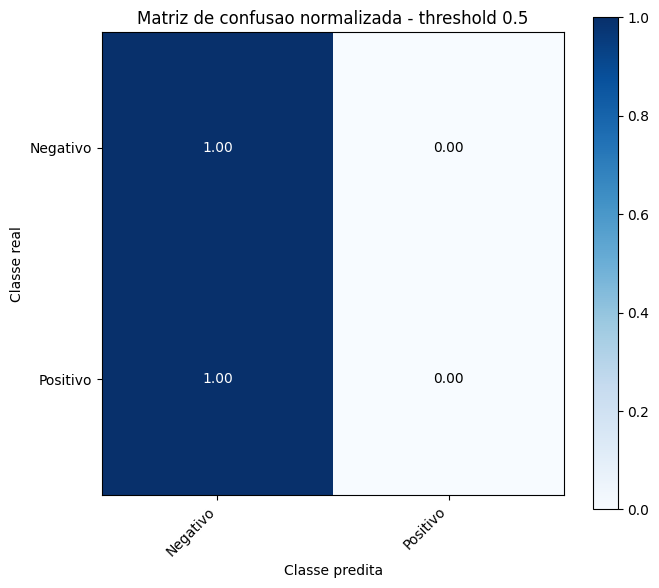

/Users/giovanna-britto/Documents/INTELI/PROJETO/g01/src/analise_visual/framework_visualizacao.py:121: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  matrix = np.divide(matrix, row_sums, where=row_sums != 0)


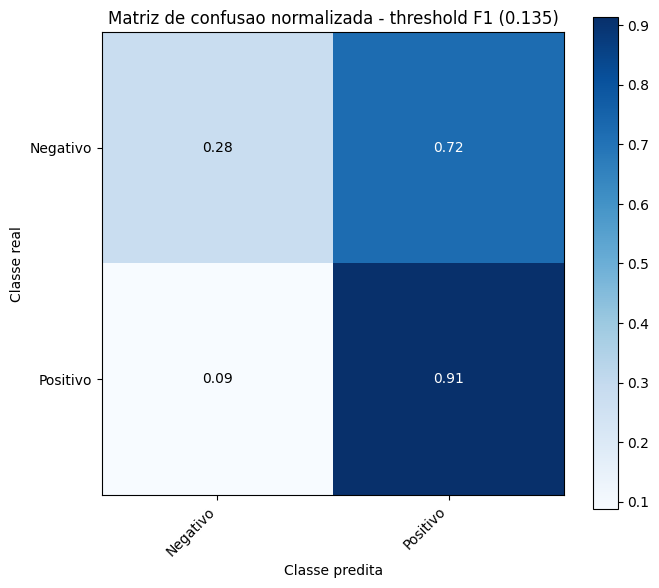

,threshold_name,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,threshold_0.5,0.5000,0.6102,0.5000,0.0000,0.000,0.0,0.6848,0.5657
1,threshold_f1,0.1345,0.5254,0.5954,0.4468,0.913,0.6,0.6848,0.5657


Metricas salvas em: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01/outputs/a09_interpretabilidade_visualizacao/test_metrics_comparison.csv


In [10]:
y_true_test = test_predictions['y_true'].to_numpy().astype(int)
y_prob_test = test_predictions['prob_pos'].to_numpy(dtype=float)

y_pred_05 = test_predictions['pred_05'].to_numpy().astype(int)
y_pred_f1 = test_predictions['pred_f1'].to_numpy().astype(int)

cm_05 = confusion_matrix(y_true_test, y_pred_05, labels=[0, 1])
cm_f1 = confusion_matrix(y_true_test, y_pred_f1, labels=[0, 1])

plot_confusion_matrix(
    cm_05,
    class_names=CLASS_NAMES,
    normalize=False,
    title='Matriz de confusao - threshold 0.5',
    save_path=OUTPUT_DIR / 'confusion_matrix_threshold_05.png',
    show=True,
)
plot_confusion_matrix(
    cm_f1,
    class_names=CLASS_NAMES,
    normalize=False,
    title=f'Matriz de confusao - threshold F1 ({threshold_f1:.3f})',
    save_path=OUTPUT_DIR / 'confusion_matrix_threshold_f1.png',
    show=True,
)
plot_confusion_matrix(
    cm_05,
    class_names=CLASS_NAMES,
    normalize=True,
    title='Matriz de confusao normalizada - threshold 0.5',
    save_path=OUTPUT_DIR / 'confusion_matrix_norm_threshold_05.png',
    show=True,
)
plot_confusion_matrix(
    cm_f1,
    class_names=CLASS_NAMES,
    normalize=True,
    title=f'Matriz de confusao normalizada - threshold F1 ({threshold_f1:.3f})',
    save_path=OUTPUT_DIR / 'confusion_matrix_norm_threshold_f1.png',
    show=True,
)

metrics_df = pd.DataFrame(
    [
        compute_binary_metrics(y_true_test, y_prob_test, 0.5, 'threshold_0.5'),
        compute_binary_metrics(y_true_test, y_prob_test, threshold_f1, 'threshold_f1'),
    ]
)
metrics_df = metrics_df.round(4)
metrics_path = OUTPUT_DIR / 'test_metrics_comparison.csv'
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print(f'Metricas salvas em: {metrics_path}')

In [11]:
tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
tn_f1, fp_f1, fn_f1, tp_f1 = cm_f1.ravel()

threshold_direction = 'mais conservador' if threshold_f1 > 0.5 else 'mais sensivel' if threshold_f1 < 0.5 else 'equivalente ao padrao'

matrix_text = f'''    ### Interpretacao das matrizes de confusao

Com `threshold=0.5`, o modelo obteve **TN={tn_05}**, **FP={fp_05}**, **FN={fn_05}** e **TP={tp_05}**. Ja com `threshold_f1={threshold_f1:.4f}`, os valores passaram para **TN={tn_f1}**, **FP={fp_f1}**, **FN={fn_f1}** e **TP={tp_f1}**.

Como o `threshold_f1` ficou **{threshold_direction}** em relacao ao corte padrao de 0.5, a comparacao ajuda a mostrar o trade-off entre **precision** e **recall**. Em prospeccao mineral, essa leitura e importante porque reduzir falsos negativos evita perder areas potencialmente promissoras, enquanto reduzir falsos positivos evita priorizar locais com menor chance real de interesse.
'''

display(Markdown(matrix_text))

    ### Interpretacao das matrizes de confusao

Com `threshold=0.5`, o modelo obteve **TN=36**, **FP=0**, **FN=23** e **TP=0**. Ja com `threshold_f1=0.1345`, os valores passaram para **TN=10**, **FP=26**, **FN=2** e **TP=21**.

Como o `threshold_f1` ficou **mais sensivel** em relacao ao corte padrao de 0.5, a comparacao ajuda a mostrar o trade-off entre **precision** e **recall**. Em prospeccao mineral, essa leitura e importante porque reduzir falsos negativos evita perder areas potencialmente promissoras, enquanto reduzir falsos positivos evita priorizar locais com menor chance real de interesse.


## Item 2.5 - Distribuicoes de probabilidade por classe

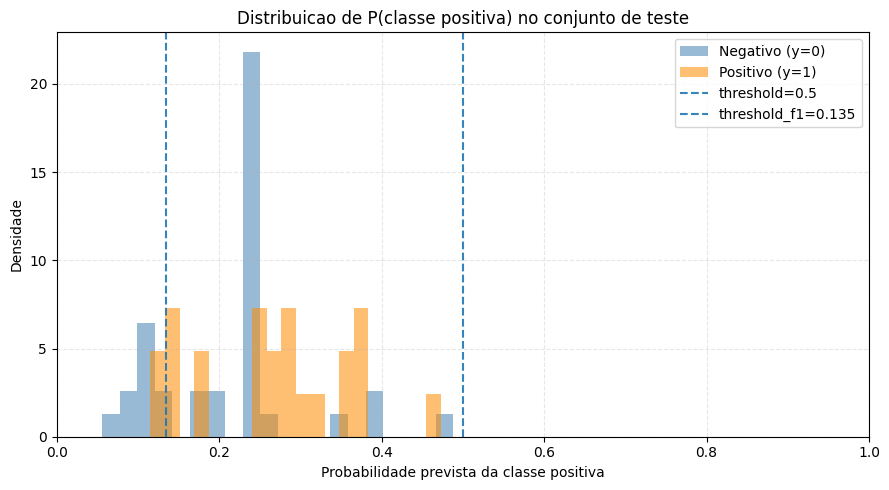

,count,mean,median,min,max
y_true,,,,,
Negativo,36,0.2165,0.2428,0.0557,0.4883
Positivo,23,0.2640,0.2745,0.1152,0.4729


Grafico salvo em: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01/outputs/a09_interpretabilidade_visualizacao/probability_distributions.png


In [12]:
plot_probability_distributions(
    y_true=y_true_test,
    y_score=y_prob_test,
    thresholds={
        'threshold=0.5': 0.5,
        f'threshold_f1={threshold_f1:.3f}': float(threshold_f1),
    },
    class_names=CLASS_NAMES,
    title='Distribuicao de P(classe positiva) no conjunto de teste',
    save_path=OUTPUT_DIR / 'probability_distributions.png',
    show=True,
)

probability_summary = (
    test_predictions.groupby('y_true')['prob_pos']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .rename(index={0: CLASS_NAMES[0], 1: CLASS_NAMES[1]})
    .round(4)
)

display(probability_summary)
print(f"Grafico salvo em: {OUTPUT_DIR / 'probability_distributions.png'}")

In [13]:
neg_mean = float(test_predictions.loc[test_predictions['y_true'] == 0, 'prob_pos'].mean())
pos_mean = float(test_predictions.loc[test_predictions['y_true'] == 1, 'prob_pos'].mean())
neg_above_05 = float((test_predictions.loc[test_predictions['y_true'] == 0, 'prob_pos'] >= 0.5).mean())
pos_above_05 = float((test_predictions.loc[test_predictions['y_true'] == 1, 'prob_pos'] >= 0.5).mean())

prob_text = f'''    ### Interpretacao das distribuicoes

As distribuicoes de `P(positivo)` mostram se o modelo separa bem as duas classes no espaco probabilistico. No conjunto de teste, a media da classe negativa foi **{neg_mean:.4f}**, enquanto a media da classe positiva foi **{pos_mean:.4f}**.

Quando a sobreposicao entre os histogramas aumenta, o modelo tende a produzir casos ambiguos proximos do threshold. Aqui, a proporcao de negativos acima de `0.5` foi **{neg_above_05:.2%}**, enquanto a proporcao de positivos acima de `0.5` foi **{pos_above_05:.2%}**. Isso ajuda a entender se o erro vem de um threshold mal posicionado ou de uma separacao probabilistica ainda limitada entre as classes.
'''

display(Markdown(prob_text))

    ### Interpretacao das distribuicoes

As distribuicoes de `P(positivo)` mostram se o modelo separa bem as duas classes no espaco probabilistico. No conjunto de teste, a media da classe negativa foi **0.2165**, enquanto a media da classe positiva foi **0.2640**.

Quando a sobreposicao entre os histogramas aumenta, o modelo tende a produzir casos ambiguos proximos do threshold. Aqui, a proporcao de negativos acima de `0.5` foi **0.00%**, enquanto a proporcao de positivos acima de `0.5` foi **0.00%**. Isso ajuda a entender se o erro vem de um threshold mal posicionado ou de uma separacao probabilistica ainda limitada entre as classes.


## Item 2.6 e 2.7 - Tabela-resumo e interpretacao critica final

In [14]:
uncertain_cases = test_predictions.assign(
    distancia_05=(test_predictions['prob_pos'] - 0.5).abs(),
    distancia_f1=(test_predictions['prob_pos'] - threshold_f1).abs(),
).sort_values('distancia_f1').head(10)

display(uncertain_cases)

,sample_id,image_id,y_true,prob_neg,prob_pos,pred_05,pred_f1,erro_05,erro_f1,distancia_05,distancia_f1
24,36293__tile_0024,36293,0,0.866473,0.133527,0,0,0,0,0.366473,0.001009
17,32431__tile_0017,32431,1,0.871899,0.128101,0,0,1,1,0.371899,0.006435
15,32388__tile_0015,32388,1,0.858663,0.141337,0,1,1,0,0.358663,0.006801
31,49914__tile_0031,49914,0,0.873738,0.126262,0,0,0,0,0.373738,0.008275
16,32392__tile_0016,32392,1,0.854469,0.145531,0,1,1,0,0.354469,0.010994
19,32471__tile_0019,32471,1,0.854117,0.145883,0,1,1,0,0.354117,0.011346
1,23350__tile_0001,23350,0,0.881127,0.118873,0,0,0,0,0.381127,0.015664
28,43257__tile_0028,43257,1,0.884795,0.115205,0,0,1,1,0.384795,0.019332
32,49915__tile_0032,49915,0,0.891404,0.108596,0,0,0,0,0.391404,0.025940
2,23576B__tile_0002,23576B,0,0.893985,0.106015,0,0,0,0,0.393985,0.028522


In [15]:
best_threshold_row = metrics_df.sort_values(['f1', 'recall', 'precision'], ascending=False).iloc[0]

final_text = f'''    ### Leitura critica consolidada

Entre os dois thresholds comparados, o melhor compromisso quantitativo no teste foi obtido por **{best_threshold_row['threshold_name']}**, com `F1={best_threshold_row['f1']:.4f}`, `recall={best_threshold_row['recall']:.4f}` e `precision={best_threshold_row['precision']:.4f}`.

A comparacao mostra que o modelo do A08 nao deve ser avaliado apenas por uma unica metrica agregada. As curvas de treino ajudam a verificar estabilidade, as matrizes de confusao explicam o tipo de erro dominante e as distribuicoes de probabilidade mostram se o threshold esta alinhado ao comportamento real do classificador.

No contexto de apoio a decisao em prospeccao, a implicacao pratica do trade-off e direta: um threshold mais baixo tende a aumentar a recuperacao de casos positivos reais, mas pode elevar o numero de falsos alarmes; um threshold mais alto reduz falsos positivos, mas aumenta o risco de deixar passar areas potencialmente relevantes. Por isso, o threshold final deve ser escolhido em funcao do custo relativo entre **FP** e **FN** na operacao.
'''

display(Markdown(final_text))

    ### Leitura critica consolidada

Entre os dois thresholds comparados, o melhor compromisso quantitativo no teste foi obtido por **threshold_f1**, com `F1=0.6000`, `recall=0.9130` e `precision=0.4468`.

A comparacao mostra que o modelo do A08 nao deve ser avaliado apenas por uma unica metrica agregada. As curvas de treino ajudam a verificar estabilidade, as matrizes de confusao explicam o tipo de erro dominante e as distribuicoes de probabilidade mostram se o threshold esta alinhado ao comportamento real do classificador.

No contexto de apoio a decisao em prospeccao, a implicacao pratica do trade-off e direta: um threshold mais baixo tende a aumentar a recuperacao de casos positivos reais, mas pode elevar o numero de falsos alarmes; um threshold mais alto reduz falsos positivos, mas aumenta o risco de deixar passar areas potencialmente relevantes. Por isso, o threshold final deve ser escolhido em funcao do custo relativo entre **FP** e **FN** na operacao.


## Item 3 - Visualizacoes espaciais ou geoespaciais

Nesta secao, conectamos as predições do modelo com as **coordenadas reais**
das amostras ASTER presentes no banco do projeto. O objetivo e observar se
existem padroes espaciais na distribuicao das probabilidades e dos erros do
classificador no conjunto de teste.

In [ ]:
EXCEL_PATH = PROJECT_ROOT / 'data' / 'banco.xlsx'
GEO_OUTPUT_CSV = OUTPUT_DIR / 'geospatial_predictions.csv'
SPATIAL_PROB_PATH = OUTPUT_DIR / 'spatial_probability_map.png'
SPATIAL_OUTCOME_PATH = OUTPUT_DIR / 'spatial_outcome_map.png'

assert EXCEL_PATH.exists(), f'Arquivo nao encontrado: {EXCEL_PATH}'

bank_df = pd.read_excel(EXCEL_PATH, sheet_name='Banco de Dados Positivo-Negativ')
bank_df['numero_amostra'] = bank_df['numero_amostra'].astype(str)

geo_predictions_df = test_predictions.copy()
geo_predictions_df['image_id'] = geo_predictions_df['image_id'].astype(str)
geo_predictions_df['y_true'] = geo_predictions_df['y_true'].astype(int)
geo_predictions_df['pred_05'] = geo_predictions_df['pred_05'].astype(int)
geo_predictions_df['pred_f1'] = geo_predictions_df['pred_f1'].astype(int)

geo_predictions_df = geo_predictions_df.merge(
    bank_df,
    left_on='image_id',
    right_on='numero_amostra',
    how='left',
)

geo_predictions_df['spatial_outcome_05'] = np.select(
    [
        (geo_predictions_df['y_true'] == 1) & (geo_predictions_df['pred_05'] == 1),
        (geo_predictions_df['y_true'] == 0) & (geo_predictions_df['pred_05'] == 0),
        (geo_predictions_df['y_true'] == 0) & (geo_predictions_df['pred_05'] == 1),
        (geo_predictions_df['y_true'] == 1) & (geo_predictions_df['pred_05'] == 0),
    ],
    ['TP', 'TN', 'FP', 'FN'],
    default='Indefinido',
)
geo_predictions_df['pred_label_05'] = geo_predicti
ons_df['pred_05'].map({0: CLASS_NAMES[0], 1: CLASS_NAMES[1]})
geo_predictions_df['true_label'] = geo_predictions_df['y_true'].map({0: CLASS_NAMES[0], 1: CLASS_NAMES[1]})

geo_predictions_df.to_csv(GEO_OUTPUT_CSV, index=False)

display_cols = [
    'sample_id', 'image_id', 'latitude_wgs84_decimal', 'longitude_wgs84_decimal',
    'prob_pos', 'pred_label_05', 'true_label', 'spatial_outcome_05'
]
display(geo_predictions_df[display_cols].head(10))
print(f'Tabela geoespacial salva em: {GEO_OUTPUT_CSV}')

In [ ]:
valid_geo_df = geo_predictions_df.dropna(subset=['latitude_wgs84_decimal', 'longitude_wgs84_decimal']).copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    valid_geo_df['longitude_wgs84_decimal'],
    valid_geo_df['latitude_wgs84_decimal'],
    c=valid_geo_df['prob_pos'],
    cmap='YlOrRd',
    s=80,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.9,
)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Probabilidade prevista da classe positiva')

top_points = valid_geo_df.nlargest(5, 'prob_pos')
for _, row in top_points.iterrows():
    ax.annotate(
        row['image_id'],
        (row['longitude_wgs84_decimal'], row['latitude_wgs84_decimal']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
    )

ax.set_title('Mapa espacial das probabilidades previstas no conjunto de teste')
ax.set_xlabel('Longitude (WGS84)')
ax.set_ylabel('Latitude (WGS84)')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(SPATIAL_PROB_PATH, dpi=150, bbox_inches='tight')
plt.show()

ranking_df = valid_geo_df[
    ['image_id', 'latitude_wgs84_decimal', 'longitude_wgs84_decimal', 'prob_pos', 'spatial_outcome_05']
].sort_values('prob_pos', ascending=False).head(10)
display(ranking_df)
print(f'Figura salva em: {SPATIAL_PROB_PATH}')

In [ ]:
outcome_colors = {'TP': '#1b9e77', 'TN': '#7570b3', 'FP': '#d95f02', 'FN': '#e7298a'}

fig, ax = plt.subplots(figsize=(10, 7))
for outcome, color in outcome_colors.items():
    subset = valid_geo_df[valid_geo_df['spatial_outcome_05'] == outcome]
    if subset.empty:
        continue
    ax.scatter(
        subset['longitude_wgs84_decimal'],
        subset['latitude_wgs84_decimal'],
        label=f'{outcome} (n={len(subset)})',
        color=color,
        s=90,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.9,
    )

ax.set_title('Distribuicao espacial de acertos e erros (threshold=0.5)')
ax.set_xlabel('Longitude (WGS84)')
ax.set_ylabel('Latitude (WGS84)')
ax.grid(True, alpha=0.25)
ax.legend(title='Resultado espacial', loc='best')
fig.tight_layout()
fig.savefig(SPATIAL_OUTCOME_PATH, dpi=150, bbox_inches='tight')
plt.show()

outcome_summary = valid_geo_df['spatial_outcome_05'].value_counts().rename_axis('resultado').reset_index(name='n_amostras')
display(outcome_summary)
print(f'Figura salva em: {SPATIAL_OUTCOME_PATH}')

In [ ]:
top_positive = valid_geo_df.nlargest(5, 'prob_pos')
fp_count = int((valid_geo_df['spatial_outcome_05'] == 'FP').sum())
fn_count = int((valid_geo_df['spatial_outcome_05'] == 'FN').sum())
tp_count = int((valid_geo_df['spatial_outcome_05'] == 'TP').sum())
tn_count = int((valid_geo_df['spatial_outcome_05'] == 'TN').sum())
max_prob = float(valid_geo_df['prob_pos'].max())
min_prob = float(valid_geo_df['prob_pos'].min())

spatial_text = f'''### Interpretacao espacial

O mapa de probabilidade mostra como o modelo distribui sua confianca ao longo das **coordenadas reais das amostras ASTER**. No conjunto de teste com coordenadas validas, as probabilidades variaram de **{min_prob:.4f}** a **{max_prob:.4f}**, o que indica heterogeneidade espacial no grau de confianca da predicao.

A leitura conjunta dos dois mapas ajuda a responder duas perguntas diferentes. O primeiro evidencia **onde o modelo concentra maior probabilidade de classe positiva**; o segundo mostra **como esses pontos se comportam em termos de acerto e erro**. No threshold 0.5, observamos **TP={tp_count}**, **TN={tn_count}**, **FP={fp_count}** e **FN={fn_count}** entre os pontos georreferenciados do teste.

Do ponto de vista pratico, os pontos com maior `prob_pos` podem ser entendidos como um **ranking espacial de priorizacao**. Ao mesmo tempo, a presenca de falsos positivos e falsos negativos mostra que a localizacao geoespacial nao elimina a necessidade de validacao: uma area com score alto continua sendo um indicio probabilistico, nao uma confirmacao geologica. Esse tipo de visualizacao e util para apoiar triagem inicial de alvos e discutir se os erros do modelo se distribuem de forma aleatoria ou se tendem a se concentrar em subregioes especificas.
'''

display(Markdown(spatial_text))
display(top_positive[['image_id', 'latitude_wgs84_decimal', 'longitude_wgs84_decimal', 'prob_pos', 'spatial_outcome_05']])

## Item 4 - Tecnicas de interpretabilidade

**Template para continuidade do grupo:**

- carregar o mesmo `best_model.keras`;
- selecionar exemplos corretos e incorretos representativos;
- aplicar uma tecnica compativel com CNN, como **Grad-CAM** ou **saliency maps**;
- comparar mapas de ativacao entre classe positiva e negativa;
- discutir se as regioes destacadas fazem sentido do ponto de vista do dominio.

## Item 5 - Sintese critica das visualizacoes

**Template para continuidade do grupo:**

- resumir os principais padroes quantitativos do item 2;
- conectar os erros observados nas matrizes com os futuros mapas e tecnicas de interpretabilidade;
- discutir limitacoes do dataset, do threshold e do proprio modelo;
- explicitar implicacoes praticas para a priorizacao de alvos de prospeccao.